# 0. NOTEBOOK PREPARATION

In [1]:
import eos
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
from IPython.display import display, Latex
#import re
import yaml
#from tabulate import tabulate
from wquantiles import quantile
from collections import OrderedDict
print(eos.__version__)

#BASE_DIRECTORY='./data_base'
BASE_DIRECTORY='./test_base'
#ANALYSIS_FILE='./an_file.yaml'
ANALYSIS_FILE='./an_file_BK.yaml'

POSTERIOR_NAME = 'BSZ-BqToK-wSR-wNFF-wCov'

def weighted_mean_std(samples, weights):
    mean = np.average(samples, weights=weights)
    var = np.average((samples - mean) ** 2, weights=weights)
    return mean, np.sqrt(var)

def find_index_for_q2(prediction, obs_name, q2_value):
    candidates = []
    for idx, item in enumerate(prediction.varied_parameters):
        if item.get('name') != obs_name:
            continue
        kin = item.get('kinematics', {})
        if 'q2' in kin:
            candidates.append((idx, float(kin['q2'])))
    if not candidates:
        return None, None
    idx, q2_best = min(candidates, key=lambda t: abs(t[1] - q2_value))
    return idx, q2_best

def range_from_pred(prediction, obs_name, q2_vals, nsigma=3.0, pad_frac=0.1):
    vals = []
    for q2 in q2_vals:
        idx, _ = find_index_for_q2(prediction, obs_name, q2)
        if idx is None:
            continue
        mean, std = weighted_mean_std(prediction.samples[:, idx], prediction.weights)
        vals.extend([mean - nsigma * std, mean + nsigma * std])
    if not vals:
        return [0.0, 1.0]
    vmin, vmax = min(vals), max(vals)
    pad = (vmax - vmin) * pad_frac if vmax != vmin else max(abs(vmin) * pad_frac, 1e-4)
    return [vmin - pad, vmax + pad]

def print_params_from_posterior(base, posterior):
    posterior_dir = os.path.join(base, 'data', posterior, 'samples')

    data = eos.data.ImportanceSamples(posterior_dir)
    samples = data.samples
    weights = data.weights
    varied = [p["name"] for p in data.varied_parameters]
    for name in varied:
        idx = varied.index(name)
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"{name}: {mean:e} ± {std:.2e}")

def print_pred_from_posterior(base, posterior, pred_name, obs_name, q2_vals):
    pred_dir = os.path.join(base, 'data', posterior, f'pred-{pred_name}')
    data = eos.data.Prediction(pred_dir)
    samples = data.samples
    weights = data.weights

    idx_q2best = []
    for q2 in q2_vals:
        idx, q2_best = find_index_for_q2(data, obs_name, q2)
        if idx is not None:
            idx_q2best.append((idx, q2_best))
    if not idx_q2best:
        print(f"No entries found for {obs_name} in {pred_name}")
        return
    for idx, q2_best in idx_q2best:
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"{obs_name} at q^2={q2_best:.1f}: {mean:e} ± {std:.2e}")

def print_ranges_from_posterior(base, posterior, nsigma=3.0): 
    posterior_dir = os.path.join(base, 'data', posterior, 'samples')

    data = eos.data.ImportanceSamples(posterior_dir)
    samples = data.samples
    weights = data.weights
    varied = [p["name"] for p in data.varied_parameters]
    for name in varied:
        idx = varied.index(name)
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"- {{ parameter: '{name}', min: {mean - nsigma * std:.3e}, max: {mean + nsigma * std:.3e}, type: 'uniform'}}")

def pred_from_posterior(base, posterior, pred_name, obs_name, q2):
    pred_dir = os.path.join(base, 'data', posterior, f'pred-{pred_name}')
    data = eos.data.Prediction(pred_dir)
    samples = data.samples
    weights = data.weights

    idx, q2_best = find_index_for_q2(data, obs_name, q2)
    if idx is None:
        print(f"No entries found for {obs_name} in {pred_name}")
        return
    
    mean, std = weighted_mean_std(samples[:, idx], weights)
    return mean, std

def weighted_mean_cov(X, w, unbiased=False):
    # X has shape (N_samples, N_observables)
    w = np.asarray(w, dtype=float)
    w = w / np.sum(w)

    #mu = np.sum(X * w[:, None], axis=0) # weighted sum with normalized weights, equivalent to average
    mu = w @ X
    Xm = X - mu
    cov = (w[:, None] * Xm).T @ Xm  # MLE weighted covariance

    if unbiased:
        neff = 1.0 / np.sum(w**2)
        if neff > 1.0:
            cov *= neff / (neff - 1.0)

    return mu, cov

1.0.19


TEMPORARY [scale variation]

In [2]:
pred_names = ['BToK-F0', 'BToK-FT0']
obs_names = ['B->K::F_plus(q2)', 'B->K::F_plus_T(q2)']
q2_vals = [-6.0,0.0,6.0]

for i in range(len(pred_names)):
    print_pred_from_posterior(BASE_DIRECTORY, POSTERIOR_NAME, pred_names[i], obs_names[i], q2_vals)

B->K::F_plus(q2) at q^2=-6.0: 3.090910e-01 ± 1.85e-02
B->K::F_plus(q2) at q^2=0.0: 3.924350e-01 ± 1.69e-02
B->K::F_plus(q2) at q^2=6.0: 5.264856e-01 ± 1.50e-02
B->K::F_plus_T(q2) at q^2=-6.0: -5.572973e-02 ± 4.16e-03
B->K::F_plus_T(q2) at q^2=0.0: 0.000000e+00 ± 0.00e+00
B->K::F_plus_T(q2) at q^2=6.0: 9.951136e-02 ± 3.23e-03


# 3. $\Delta C_{9,7}$ evaluation

## 3.1 Check with Nico's nb

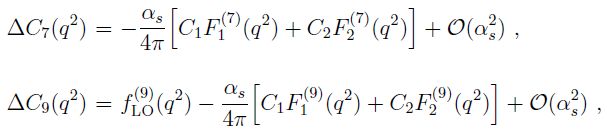

Nico's values from Méril's NB:

In [13]:
# Nico's points are [Re(dC7(-7)), Im(dC7(-7)), Re(dC9(-7)), Im(dC9(-7)), Re(dC7(-5)), Im(dC7(-5)), Re(dC9(-5)), Im(dC9(-5)), Re(dC7(-3)), Im(dC7(-3)), Re(dC9(-3)), Im(dC9(-3)), Re(dC7(-1)), Im(dC7(-1)), Re(dC9(-1)), Im(dC9(-1))]
np.array([
    -0.04772609914476168, -0.00183730036829226, 0.07853072280327339, 0.000908821307728336,
    -0.05001585076240161, -0.00217806915487611, 0.10502127454492018, 0.000967628009215721,
    -0.05247358603064688, -0.00262107339844842, 0.13497045338769842, 0.000989307736797652,
    -0.05510828431004989, -0.003209557376766988, 0.16960820080628938, 0.0009129068295559907
])

array([-0.0477261 , -0.0018373 ,  0.07853072,  0.00090882, -0.05001585,
       -0.00217807,  0.10502127,  0.00096763, -0.05247359, -0.00262107,
        0.13497045,  0.00098931, -0.05510828, -0.00320956,  0.1696082 ,
        0.00091291])

In [2]:
# OBSOLETE: used just to compare with 'myDeltaC_Qc' for WC_number = '7'

# For now only valid for WC_number = '7' bc I have to add the LO for '9'
def DeltaC(WC_number, diag_class, s_Re, s_Im):

    if WC_number == '9':
        fLO = 0  # Placeholder for future implementation
    else:
        fLO = 0

    test_flag = 0
    
    p = eos.Parameters.Defaults()

    # C1 = p['b->s::c1'].evaluate()
    # C2 = p['b->s::c2'].evaluate()
    C1 = -0.287213
    C2 = 1.009
    p.set("mass::b(MSbar)", 4.18)
    p.set("mass::c", 1.44423)
    #p.set("mass::c", 1.2122)
    p.set("sb::mu", 4.18)
    alpha_s = 0.226964 # from Nico's Mathematica at mu_b = 4.18

    q2_Re = s_Re 
    q2_Im = s_Im 

    kinematics = {"Re{q2}": q2_Re, "Im{q2}": q2_Im}

    # build observable names for the C1 and C2 contributions
    re_name1 = "b->s::Re{{{}}}(Re{{q2}},Im{{q2}})".format(f"F1{WC_number}")
    im_name1 = "b->s::Im{{{}}}(Re{{q2}},Im{{q2}})".format(f"F1{WC_number}")
    re_name2 = "b->s::Re{{{}}}(Re{{q2}},Im{{q2}})".format(f"F2{WC_number}")
    im_name2 = "b->s::Im{{{}}}(Re{{q2}},Im{{q2}})".format(f"F2{WC_number}")

    if test_flag:
        print("Observable names:")
        print(re_name1)
        print(im_name1)
        print(re_name2)
        print(im_name2)

    # make observables and evaluate
    real_part1 = eos.Observable.make(re_name1, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()
    imag_part1 = eos.Observable.make(im_name1, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()
    real_part2 = eos.Observable.make(re_name2, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()
    imag_part2 = eos.Observable.make(im_name2, p, eos.Kinematics(kinematics), eos.Options({"contribution": diag_class})).evaluate()

    if test_flag:
        print("Real and Imaginary parts:")
        print("C1 contribution: Re = {}, Im = {}".format(real_part1, imag_part1))
        print("C2 contribution: Re = {}, Im = {}".format(real_part2, imag_part2))

    # Must add the fLO

    DC_Re = - alpha_s/(4.0*np.pi) * (C1*real_part1 + C2*real_part2)
    DC_Im = - alpha_s/(4.0*np.pi) * (C1*imag_part1 + C2*imag_part2)

    return DC_Re + 1j * DC_Im


def myDeltaC_Qc(WC_number, s_Re):

    test_flag = 0
    
    p = eos.Parameters.Defaults()
    p.set('b->s::c1', -0.287213)
    p.set('b->s::c2', 1.009)
    p.set("mass::b(MSbar)", 4.18)
    p.set("mass::c", 1.44423)
    p.set("sb::mu", 4.18)
    #alpha_s = 0.226964 # from Nico's Mathematica at mu_b = 4.18

    q2_Re = s_Re 
    kinematics = {"q2": q2_Re}

    re_name = "b->s::Re{{{}}}(q2)".format(f"Delta_C{WC_number}_Qc")
    im_name = "b->s::Im{{{}}}(q2)".format(f"Delta_C{WC_number}_Qc")

    if test_flag:
        print("Observable names:")
        print(re_name)
        print(im_name)

    # make observables and evaluate
    real_part = eos.Observable.make(re_name, p, eos.Kinematics(kinematics), eos.Options({"model":"WET"})).evaluate()
    imag_part = eos.Observable.make(im_name, p, eos.Kinematics(kinematics), eos.Options({"model":"WET"})).evaluate()

    if test_flag:
        print("Real and Imaginary parts:")
        print("Re = {}, Im = {}".format(real_part, imag_part))

    # Must add the fLO

    DC_Re = real_part
    DC_Im = imag_part

    return DC_Re + 1j * DC_Im

def myDeltaC_Qc_LO(WC_number, s_Re):

    test_flag = 0
    
    p = eos.Parameters.Defaults()
    p.set('b->s::c1', -0.287213)
    p.set('b->s::c2', 1.009)
    p.set("mass::b(MSbar)", 4.18)
    p.set("mass::c", 1.44423)
    p.set("sb::mu", 4.18)
    #alpha_s = 0.226964 # from Nico's Mathematica at mu_b = 4.18

    q2_Re = s_Re 
    kinematics = {"q2": q2_Re}

    re_name = "b->s::Re{{{}}}(q2)".format(f"Delta_C{WC_number}_Qc_LO")
    im_name = "b->s::Im{{{}}}(q2)".format(f"Delta_C{WC_number}_Qc_LO")

    if test_flag:
        print("Observable names:")
        print(re_name)
        print(im_name)

    # make observables and evaluate
    real_part = eos.Observable.make(re_name, p, eos.Kinematics(kinematics), eos.Options({"model":"SM"})).evaluate()
    imag_part = eos.Observable.make(im_name, p, eos.Kinematics(kinematics), eos.Options({"model":"SM"})).evaluate()

    if test_flag:
        print("Real and Imaginary parts:")
        print("Re = {}, Im = {}".format(real_part, imag_part))

    # Must add the fLO

    DC_Re = real_part
    DC_Im = imag_part

    return DC_Re + 1j * DC_Im



In [3]:
q2_values = [-7.0, -5.0, -3.0, -1.0]

for q2 in q2_values:
    print("q2 = {} GeV^2".format(q2))
    print(myDeltaC_Qc('7', q2), myDeltaC_Qc('9', q2))
    print(myDeltaC_Qc_LO('9', q2))

q2 = -7.0 GeV^2
(-0.04785687214951035-0.0018451397299937692j) (0.07859760689425559+0.0009145900364157491j)
(0.1701258921896638+1.1228968356171364e-12j)
q2 = -5.0 GeV^2
(-0.05015296745356085-0.0021873370327390802j) (0.10510926413421107+0.0009743117293601142j)
(0.20301277723004915+1.2960544161466734e-12j)
q2 = -3.0 GeV^2
(-0.05261760650259805-0.0026321930782734837j) (0.1350840713533475+0.0009971777825040988j)
(0.24060316948841778+1.5216413135598463e-12j)
q2 = -1.0 GeV^2
(-0.05525980203901541-0.0032231368079881613j) (0.16975385884886668+0.0009224329814836416j)
(0.28452852495271874+1.829074597862331e-12j)


In [6]:
# Nico's points are [Re(dC7(-7)), Im(dC7(-7)), Re(dC9(-7)), Im(dC9(-7)), Re(dC7(-5)), Im(dC7(-5)), Re(dC9(-5)), Im(dC9(-5)), Re(dC7(-3)), Im(dC7(-3)), Re(dC9(-3)), Im(dC9(-3)), Re(dC7(-1)), Im(dC7(-1)), Re(dC9(-1)), Im(dC9(-1))]
mean = np.array([
    -0.04772609914476168, -0.00183730036829226, 0.07853072280327339, 0.000908821307728336,
    -0.05001585076240161, -0.00217806915487611, 0.10502127454492018, 0.000967628009215721,
    -0.05247358603064688, -0.00262107339844842, 0.13497045338769842, 0.000989307736797652,
    -0.05510828431004989, -0.003209557376766988, 0.16960820080628938, 0.0009129068295559907
])

# 4. Non-Local FF

## 4.0 $H_0^{B \to K}(q^2;F)$

Inserting custom observables ...
Inserted observable: B->K::Re{H_0(q2,F)}
Inserted observable: B->K::Im{H_0(q2,F)}
Inserted observable: B->K::Re{Delta_H_0(q2)}/Re{H_0(q2,F)}
Inserted observable: B->K::Im{Delta_H_0(q2)}/Im{H_0(q2,F)}
... finished inserting 4 custom observables


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK-wSR/plot…

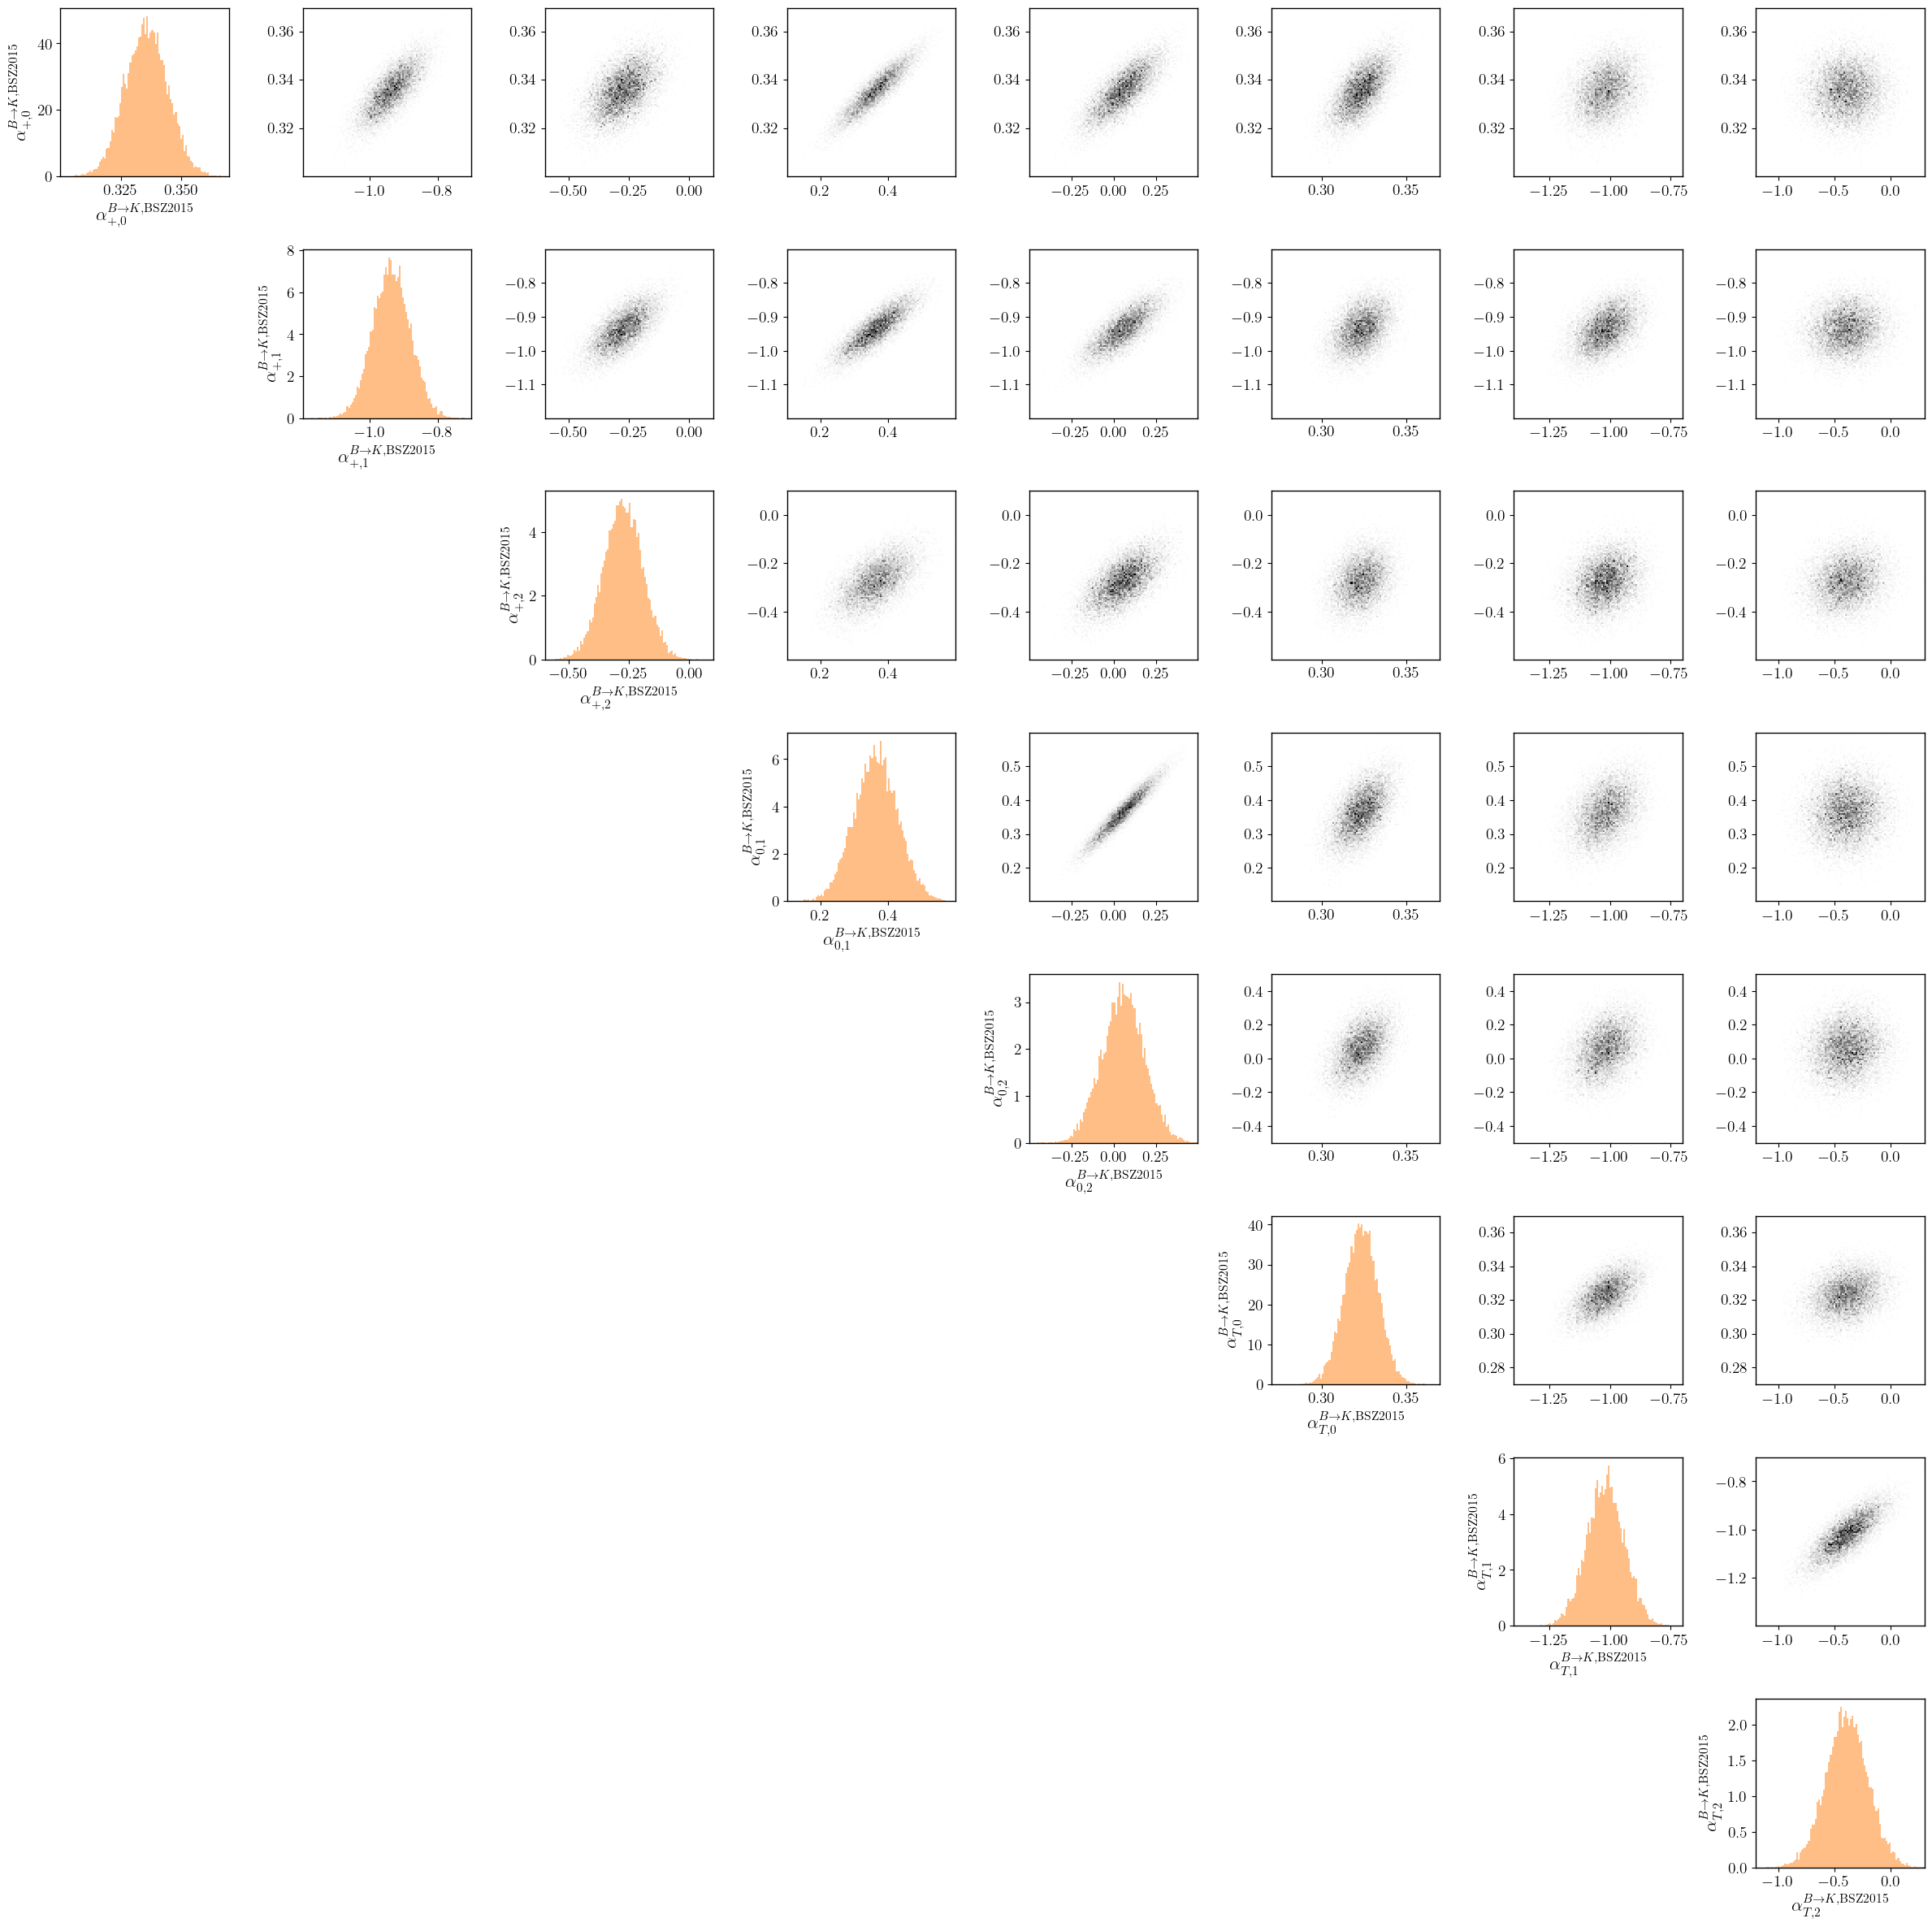

In [2]:
eos.tasks.corner_plot(ANALYSIS_FILE, 'BSZ-BqToK-wSR', TEST_BASE_DIRECTORY)

In [3]:
bfp, gof  = eos.tasks.find_mode(ANALYSIS_FILE, 'BSZ-BqToK-wSR', BASE_DIRECTORY, importance_samples=True, label='EOS', optimizations=100)
display(bfp)
display(gof)

Inserting custom observables ...
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{H_0(q2,F)} has been replaced.
Inserted observable: B->K::Re{H_0(q2,F)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{H_0(q2,F)} has been replaced.
Inserted observable: B->K::Im{H_0(q2,F)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{Delta_H_0(q2)}/Re{H_0(q2,F)} has been replaced.
Inserted observable: B->K::Re{Delta_H_0(q2)}/Re{H_0(q2,F)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{Delta_H_0(q2)}/Im{H_0(q2,F)} has been replaced.
Inserted observable: B->K::Im{Delta_H_0(q2)}/Im{H_0(q2,F)}
... finished inserting 4 custom observables


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK-wSR/mode…

parameter,value
"$\alpha_{+,0}^{B \to K,\mathrm{BSZ2015}}$",0.3354
"$\alpha_{+,1}^{B \to K,\mathrm{BSZ2015}}$",-0.9371
"$\alpha_{+,2}^{B \to K,\mathrm{BSZ2015}}$",-0.2756
"$\alpha_{0,1}^{B \to K,\mathrm{BSZ2015}}$",0.3631
"$\alpha_{0,2}^{B \to K,\mathrm{BSZ2015}}$",0.0542
"$\alpha_{T,0}^{B \to K,\mathrm{BSZ2015}}$",0.3231
"$\alpha_{T,1}^{B \to K,\mathrm{BSZ2015}}$",-1.0194
"$\alpha_{T,2}^{B \to K,\mathrm{BSZ2015}}$",-0.3917


In [24]:
pred_names = ['pred-BToK-Re(H0(F))', 'pred-BToK-Im(H0(F))']
obs_names = ['B->K::Re{H_0(q2,F)}', 'B->K::Im{H_0(q2,F)}']
q2_vals = [-7.0, -5.0, -3.0, -1.0]
for pred_name, obs_name in zip(pred_names, obs_names):
    print_pred_from_posterior(TEST_BASE_DIRECTORY, 'BSZ-BqToK-wSR', pred_name, obs_name, q2_vals)

B->K::Re{H_0(q2,F)} at q^2=-7.0: -1.117179e-04 ± 4.08e-06
B->K::Re{H_0(q2,F)} at q^2=-5.0: -8.519247e-05 ± 2.82e-06
B->K::Re{H_0(q2,F)} at q^2=-3.0: -4.557991e-05 ± 1.36e-06
B->K::Re{H_0(q2,F)} at q^2=-1.0: -8.754213e-06 ± 2.33e-07
B->K::Im{H_0(q2,F)} at q^2=-7.0: -1.674778e-06 ± 6.03e-08
B->K::Im{H_0(q2,F)} at q^2=-5.0: -1.163021e-06 ± 3.82e-08
B->K::Im{H_0(q2,F)} at q^2=-3.0: -6.492212e-07 ± 1.99e-08
B->K::Im{H_0(q2,F)} at q^2=-1.0: -1.958016e-07 ± 5.95e-09


## 4.1 Predictions for $Q_c$ Non-Local FF in $B \to K$

In [ ]:
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK-wSR', 'BToK-Re(H0/F0)', base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK-wSR', 'BToK-Im(H0/F0)', base_directory=BASE_DIRECTORY)

Inserting custom observables ...
Inserted observable: B->K::Re{H0(q2)/F0(q2)}
Inserted observable: B->K::Im{H0(q2)/F0(q2)}
... finished inserting 2 custom observables


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK-wSR/pred…

In [ ]:
# Numeric estimates for Re/Im H0/F0 at selected q2 points
pred_re = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', 'BSZ-BqToK-wSR', 'pred-BToK-Re(H0/F0)'))
pred_im = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', 'BSZ-BqToK-wSR', 'pred-BToK-Im(H0/F0)'))

q2_values = [-7.0, -5.0, -3.0, -1.0]
obs_re = 'B->K::Re{H0(q2)/F0(q2)}'
obs_im = 'B->K::Im{H0(q2)/F0(q2)}'

for q2 in q2_values:
    idx_re, q2_re = find_index_for_q2(pred_re, obs_re, q2)
    idx_im, q2_im = find_index_for_q2(pred_im, obs_im, q2)
    if idx_re is None or idx_im is None:
        print(f'q2 = {q2}: no matching prediction entry found')
        continue
    re_mean, re_std = weighted_mean_std(pred_re.samples[:, idx_re], pred_re.weights)
    im_mean, im_std = weighted_mean_std(pred_im.samples[:, idx_im], pred_im.weights)
    print(f'q2 = {q2} (used {q2_re}): Re = {re_mean:.6e} ± {re_std:.6e}; Im = {im_mean:.6e} ± {im_std:.6e}')

q2 = -7.0 (used -7.0): Re = -1.151664e-04 ± 4.259665e-06; Im = -1.669767e-06 ± 6.061664e-08
q2 = -5.0 (used -5.0): Re = -8.747757e-05 ± 2.930912e-06; Im = -1.159684e-06 ± 3.838023e-08
q2 = -3.0 (used -3.0): Re = -4.664766e-05 ± 1.404221e-06; Im = -6.474601e-07 ± 1.997087e-08
q2 = -1.0 (used -1.0): Re = -8.905964e-06 ± 2.390404e-07; Im = -1.953122e-07 ± 5.996508e-09


   plotting uncertainty propagation from "./data_base/data/BSZ-BqToK-wSR/pred-BToK-Re(H0/F0)"


   plotting uncertainty propagation from "./data_base/data/BSZ-BqToK-wSR/pred-BToK-Im(H0/F0)"


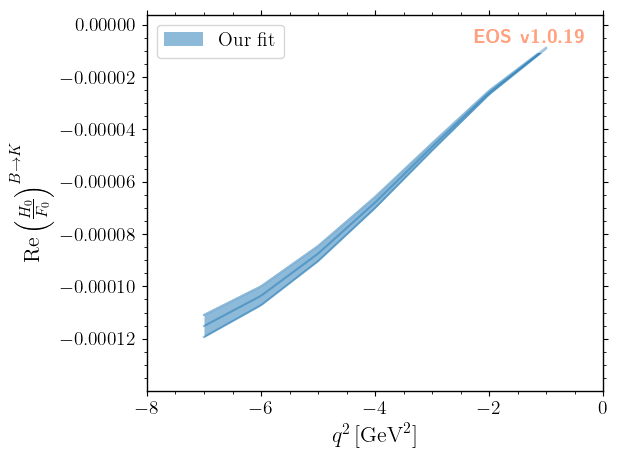

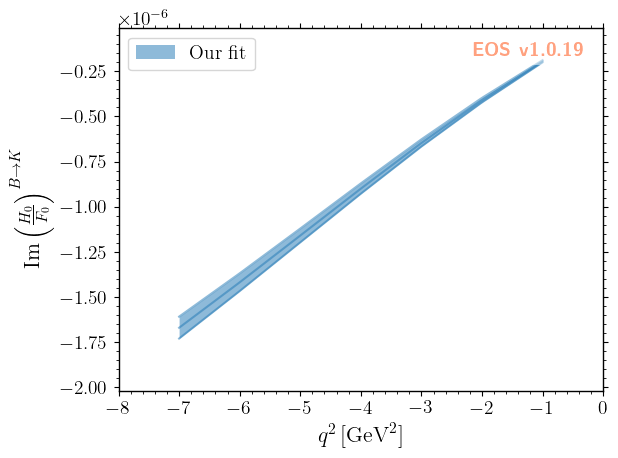

In [ ]:
# Plot Re/Im with y-range inferred from the previous prediction output

q2_vals = [-7.0, -5.0, -3.0, -1.0]
pred_re = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', 'BSZ-BqToK-wSR', 'pred-BToK-Re(H0/F0)'))
pred_im = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', 'BSZ-BqToK-wSR', 'pred-BToK-Im(H0/F0)'))
obs_re = 'B->K::Re{H0(q2)/F0(q2)}'
obs_im = 'B->K::Im{H0(q2)/F0(q2)}'

form_factors = [
    (obs_re, R'\mathrm{Re}\left(\frac{H_0}{F_0}\right)^{B \to K}', range_from_pred(pred_re, obs_re, q2_vals), 'BToK-Re(H0/F0)'),
    (obs_im, R'\mathrm{Im}\left(\frac{H_0}{F_0}\right)^{B \to K}', range_from_pred(pred_im, obs_im, q2_vals), 'BToK-Im(H0/F0)')
  ]
for qn, latex, yrange, pred in form_factors:
	plot_args = {
		'plot': {
			'x': { 'label': r'$q^2$',      'unit': r'$\textnormal{GeV}^2$', 'range': [-8.0, 0.0] },
			'y': { 'label': fr'${latex}$',                                  'range': yrange         },
			'legend': { 'location': 'upper left' }
		},
		'contents': [
			{
          		'label': r'Our fit','type': 'uncertainty', 'range': [-8.0, 0.0],
				'color': 'C0',
          		'data-file': f'{BASE_DIRECTORY}/data/BSZ-BqToK-wSR/pred-{pred}'
			}
		],
	}
	eos.plot.Plotter(plot_args).plot()

### 4.1.1 Check numerical values

In [16]:
print(myDeltaC_Qc('7', -7.0))
print(myDeltaC_Qc('9', -7.0))

(-0.04785687214951035-0.0018451397299937692j)
(0.07859760689425559+0.0009145900364157491j)


In [22]:
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK-wSR', 'BToK-F0', base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK-wSR', 'BToK-FT0/F0', base_directory=BASE_DIRECTORY)

Inserting custom observables ...
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{H0(q2)/F0(q2)} has been replaced.
Inserted observable: B->K::Re{H0(q2)/F0(q2)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{H0(q2)/F0(q2)} has been replaced.
Inserted observable: B->K::Im{H0(q2)/F0(q2)}
... finished inserting 2 custom observables


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK-wSR/pred…

Inserting custom observables ...
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{H0(q2)/F0(q2)} has been replaced.
Inserted observable: B->K::Re{H0(q2)/F0(q2)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{H0(q2)/F0(q2)} has been replaced.
Inserted observable: B->K::Im{H0(q2)/F0(q2)}
... finished inserting 2 custom observables


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK-wSR/pred…

## 4.2 Prediction for $Q_c$ NL-FF in $B \to K^*$

In [4]:
eos.Observables(prefix= 'B->K');

In [2]:
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK*-wSR', 'BToK*-Re(H0/F0)', base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables('./an_file.yaml', 'BSZ-BqToK*-wSR', 'BToK*-Im(H0/F0)', base_directory=BASE_DIRECTORY)

Inserting custom observables ...


Inserted observable: B->K::Re{H0(q2)/F0(q2)}
Inserted observable: B->K::Im{H0(q2)/F0(q2)}
Inserted observable: B->K^*::Re{H_0(q2)/F_0(q2)}
Inserted observable: B->K^*::Im{H_0(q2)/F_0(q2)}
Inserted observable: B->K^*::Re{H_perp(q2)/F_perp(q2)}
Inserted observable: B->K^*::Im{H_perp(q2)/F_perp(q2)}
Inserted observable: B->K^*::Re{H_para(q2)/F_para(q2)}
Inserted observable: B->K^*::Im{H_para(q2)/F_para(q2)}
... finished inserting 8 custom observables


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK*-wSR/pre…

Inserting custom observables ...
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{H0(q2)/F0(q2)} has been replaced.
Inserted observable: B->K::Re{H0(q2)/F0(q2)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{H0(q2)/F0(q2)} has been replaced.
Inserted observable: B->K::Im{H0(q2)/F0(q2)}
[ObservableEntries.insert_or_assign] Entry for observable B->K^*::Re{H_0(q2)/F_0(q2)} has been replaced.
Inserted observable: B->K^*::Re{H_0(q2)/F_0(q2)}
[ObservableEntries.insert_or_assign] Entry for observable B->K^*::Im{H_0(q2)/F_0(q2)} has been replaced.
Inserted observable: B->K^*::Im{H_0(q2)/F_0(q2)}
[ObservableEntries.insert_or_assign] Entry for observable B->K^*::Re{H_perp(q2)/F_perp(q2)} has been replaced.
Inserted observable: B->K^*::Re{H_perp(q2)/F_perp(q2)}
[ObservableEntries.insert_or_assign] Entry for observable B->K^*::Im{H_perp(q2)/F_perp(q2)} has been replaced.
Inserted observable: B->K^*::Im{H_perp(q2)/F_perp(q2)}
[ObservableEntries.insert_or_assign

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK*-wSR/pre…

## 4.3 $B \to K$ NL-FF: Fit

In [3]:
print_ranges_from_posterior(BASE_DIRECTORY, POSTERIOR_NAME, nsigma=3.0)

- { parameter: 'B->K::alpha^f+_0@BSZ2015', min: 3.276e-01, max: 4.451e-01, type: 'uniform'}
- { parameter: 'B->K::alpha^f+_1@BSZ2015', min: -1.053e+00, max: -7.297e-02, type: 'uniform'}
- { parameter: 'B->K::alpha^f+_2@BSZ2015', min: -7.481e-01, max: 1.459e+00, type: 'uniform'}
- { parameter: 'B->K::alpha^f0_1@BSZ2015', min: 2.827e-01, max: 1.148e+00, type: 'uniform'}
- { parameter: 'B->K::alpha^f0_2@BSZ2015', min: -1.134e-01, max: 1.422e+00, type: 'uniform'}
- { parameter: 'B->K::alpha^fT_0@BSZ2015', min: 3.026e-01, max: 4.265e-01, type: 'uniform'}
- { parameter: 'B->K::alpha^fT_1@BSZ2015', min: -1.272e+00, max: -1.544e-01, type: 'uniform'}
- { parameter: 'B->K::alpha^fT_2@BSZ2015', min: -1.192e+00, max: 1.313e+00, type: 'uniform'}


Inserting custom observables ...
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C7_Qc}(-7) has been replaced.
Inserted observable: b->s::Re{Delta_C7_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C7_Qc}(-7) has been replaced.
Inserted observable: b->s::Im{Delta_C7_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C9_Qc}(-7) has been replaced.
Inserted observable: b->s::Re{Delta_C9_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C9_Qc}(-7) has been replaced.
Inserted observable: b->s::Im{Delta_C9_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C7_Qc}(-5) has been replaced.
Inserted observable: b->s::Re{Delta_C7_Qc}(-5)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C7_Qc}(-5) has been replaced.
Inserted observable: b->s::Im{Delta_C7_Qc}(-5)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{

Inserted observable: B->K::Re{H_0(-1,F)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{H_0(-1,F)} has been replaced.
Inserted observable: B->K::Im{H_0(-1,F)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{Delta_H_0(-7)}/F_0(q2) has been replaced.
Inserted observable: B->K::Re{Delta_H_0(-7)}/F_0(q2)
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{Delta_H_0(-7)}/F_0(q2) has been replaced.
Inserted observable: B->K::Im{Delta_H_0(-7)}/F_0(q2)
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{Delta_H_0(-5)}/F_0(q2) has been replaced.
Inserted observable: B->K::Re{Delta_H_0(-5)}/F_0(q2)
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{Delta_H_0(-5)}/F_0(q2) has been replaced.
Inserted observable: B->K::Im{Delta_H_0(-5)}/F_0(q2)
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{Delta_H_0(-3)}/F_0(q2) has been replaced.
Inserted observable: B->K::Re{Delta_H_0(-3)}/F_0(q2)
[Observable

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK-wSR-wNFF…

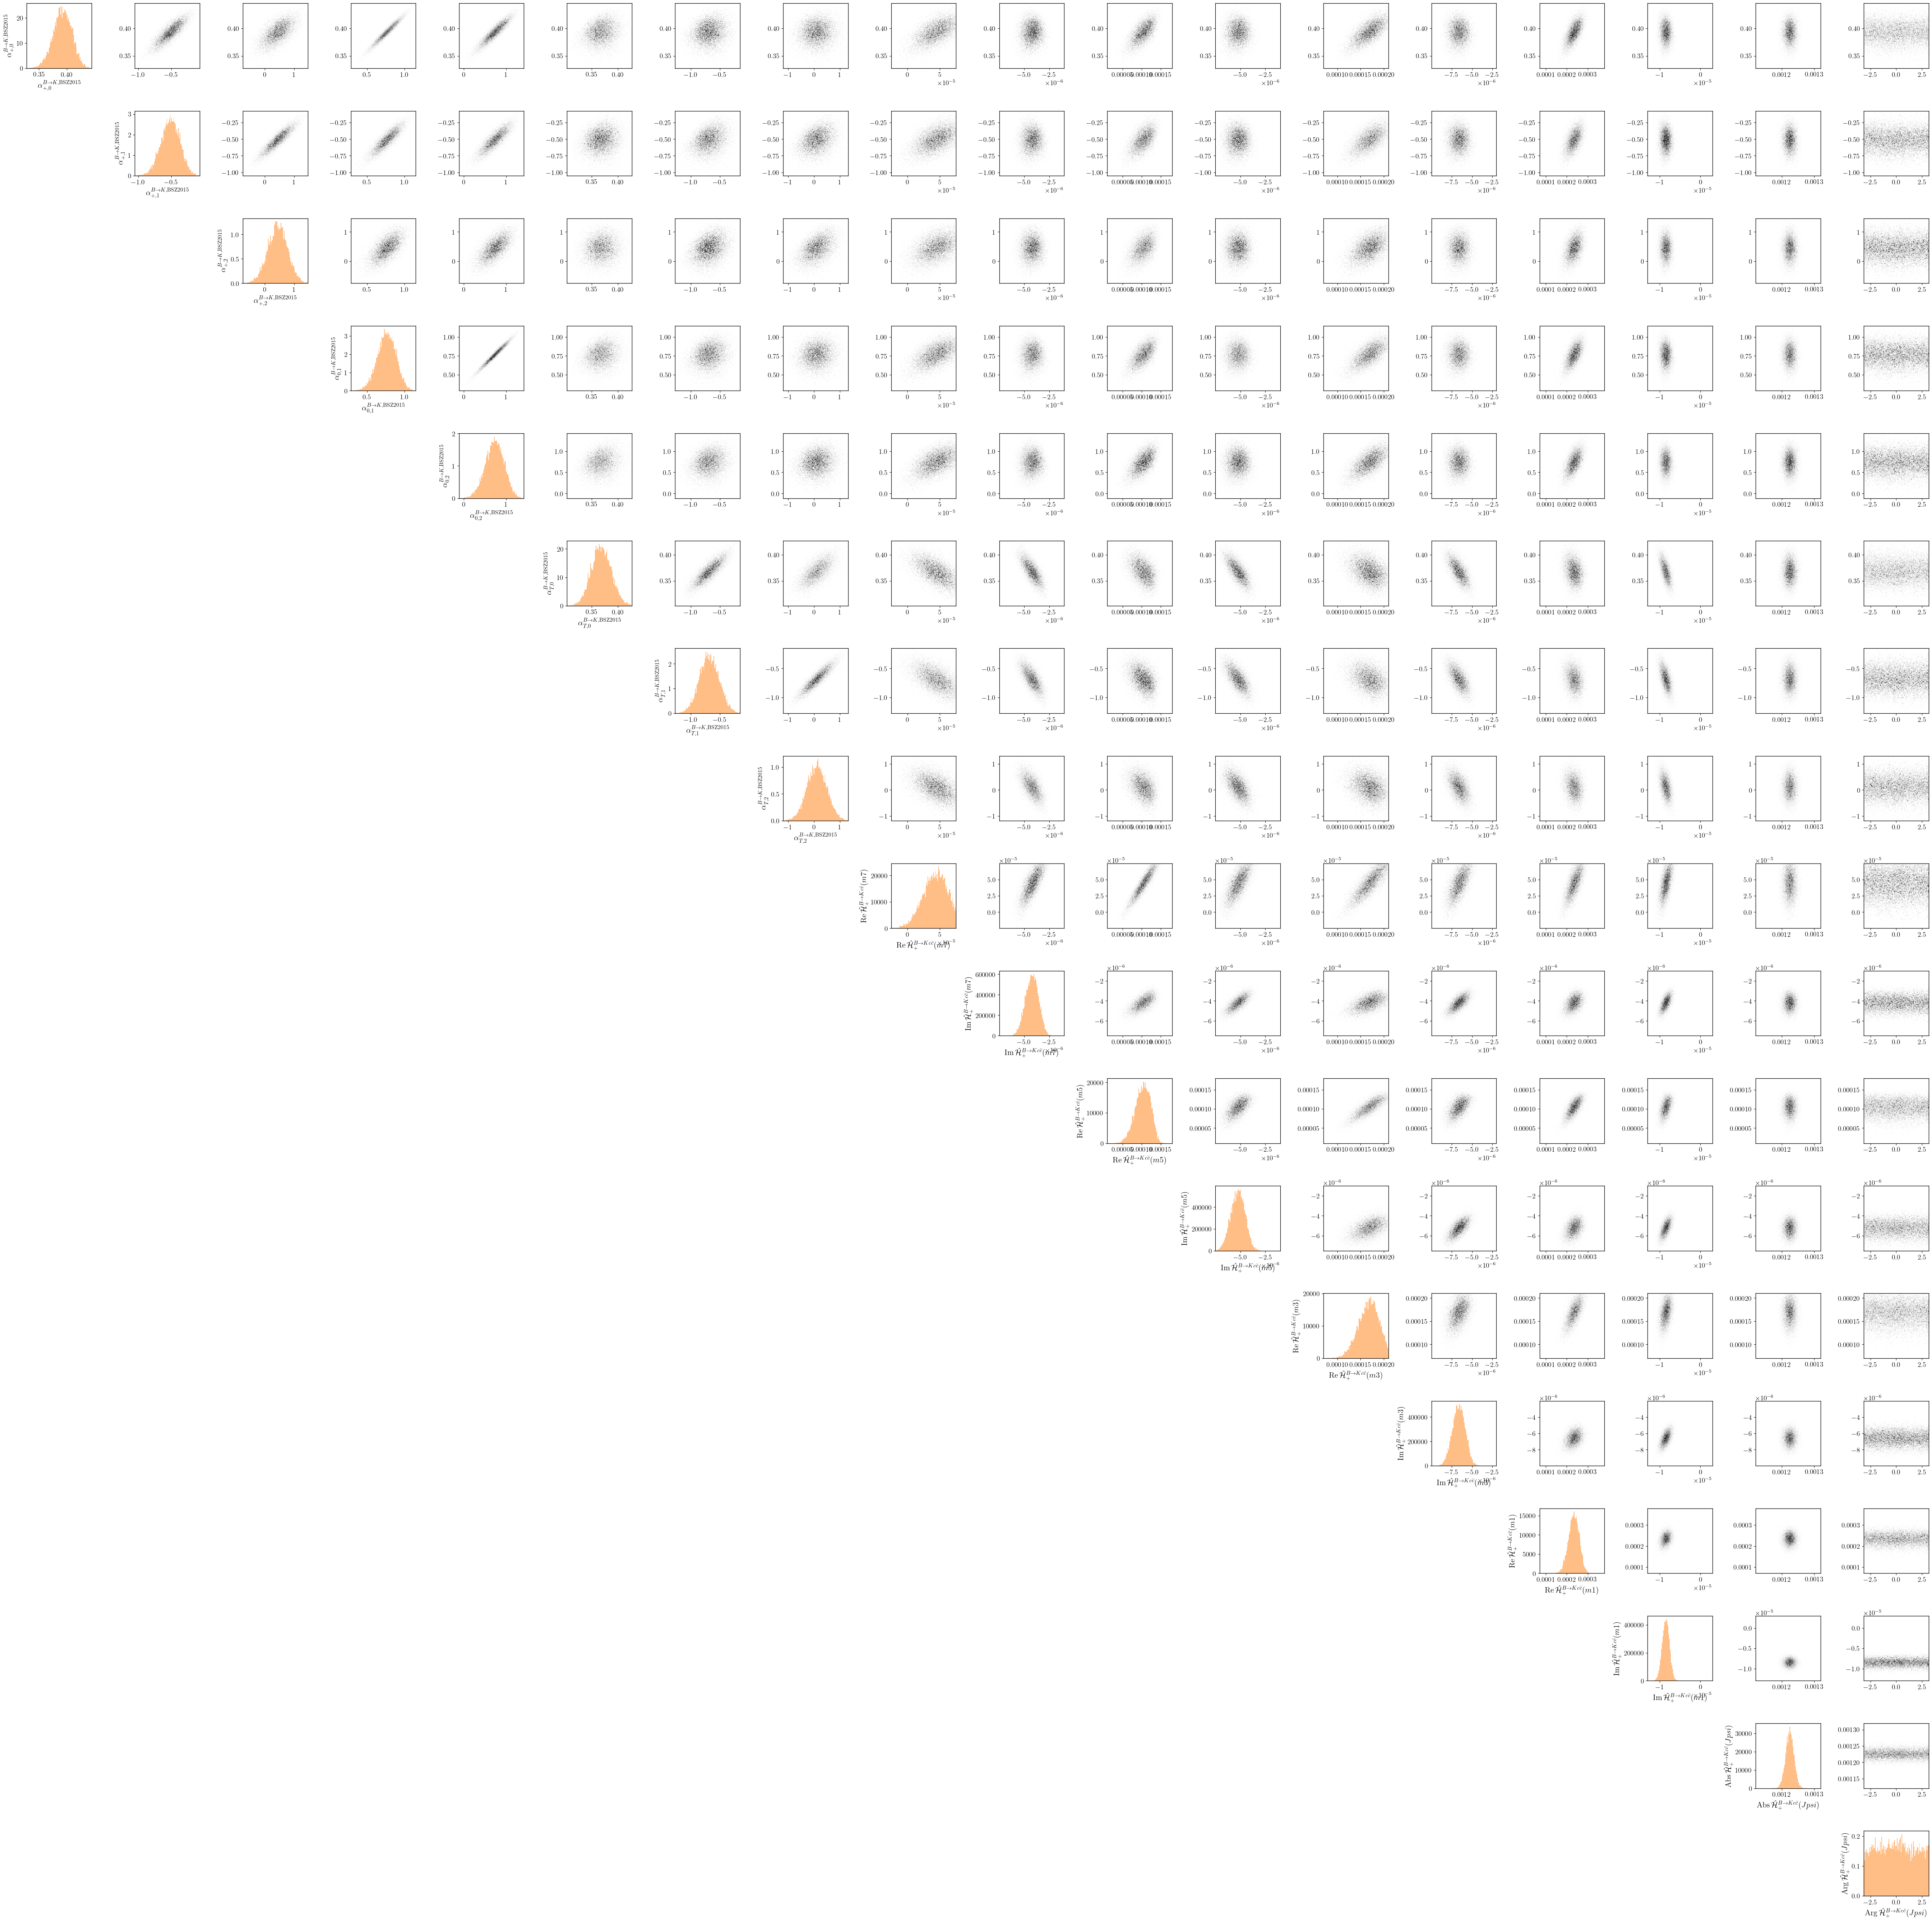

In [5]:
eos.tasks.corner_plot(ANALYSIS_FILE, POSTERIOR_NAME, BASE_DIRECTORY)

In [6]:
bfp, gof = eos.tasks.find_mode(
        ANALYSIS_FILE,
        POSTERIOR_NAME,
        BASE_DIRECTORY,
        importance_samples=True,
        label='EOS',
        optimizations=50
    )
display(bfp)
display(gof)

Inserting custom observables ...
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C7_Qc}(-7) has been replaced.
Inserted observable: b->s::Re{Delta_C7_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C7_Qc}(-7) has been replaced.
Inserted observable: b->s::Im{Delta_C7_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C9_Qc}(-7) has been replaced.
Inserted observable: b->s::Re{Delta_C9_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C9_Qc}(-7) has been replaced.
Inserted observable: b->s::Im{Delta_C9_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C7_Qc}(-5) has been replaced.
Inserted observable: b->s::Re{Delta_C7_Qc}(-5)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C7_Qc}(-5) has been replaced.
Inserted observable: b->s::Im{Delta_C7_Qc}(-5)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{

Inserted observable: b->s::Re{Delta_C7_Qc}(-1)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C7_Qc}(-1) has been replaced.
Inserted observable: b->s::Im{Delta_C7_Qc}(-1)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C9_Qc}(-1) has been replaced.
Inserted observable: b->s::Re{Delta_C9_Qc}(-1)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C9_Qc}(-1) has been replaced.
Inserted observable: b->s::Im{Delta_C9_Qc}(-1)
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{H_0(-7,F)} has been replaced.
Inserted observable: B->K::Re{H_0(-7,F)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{H_0(-7,F)} has been replaced.
Inserted observable: B->K::Im{H_0(-7,F)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{H_0(-5,F)} has been replaced.
Inserted observable: B->K::Re{H_0(-5,F)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{H_0(-5,F)} has been re

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK-wSR-wNFF…

parameter,value
"$\alpha_{+,0}^{B \to K,\mathrm{BSZ2015}}$",0.3867
"$\alpha_{+,1}^{B \to K,\mathrm{BSZ2015}}$",-0.5602
"$\alpha_{+,2}^{B \to K,\mathrm{BSZ2015}}$",0.3621
"$\alpha_{0,1}^{B \to K,\mathrm{BSZ2015}}$",0.7174
"$\alpha_{0,2}^{B \to K,\mathrm{BSZ2015}}$",0.6575
"$\alpha_{T,0}^{B \to K,\mathrm{BSZ2015}}$",0.3647
"$\alpha_{T,1}^{B \to K,\mathrm{BSZ2015}}$",-0.7124
"$\alpha_{T,2}^{B \to K,\mathrm{BSZ2015}}$",0.0627
"$\mathrm{Re}\, \hat{\mathcal{H}}_+^{B\to Kc\bar{c}}(m7)$",0.0000
"$\mathrm{Im}\, \hat{\mathcal{H}}_+^{B\to Kc\bar{c}}(m7)$",-0.0000


   plotting uncertainty propagation from "./test_base/data/BSZ-BqToK-wSR-wNFF-wCov/pred-BToK-f+"
   plotting uncertainty propagation from "./test_base/data/BSZ-BqToK-wSR-wNFF-wCov/pred-BToK-f0"
   plotting uncertainty propagation from "./test_base/data/BSZ-BqToK-wSR-wNFF-wCov/pred-BToK-fT"


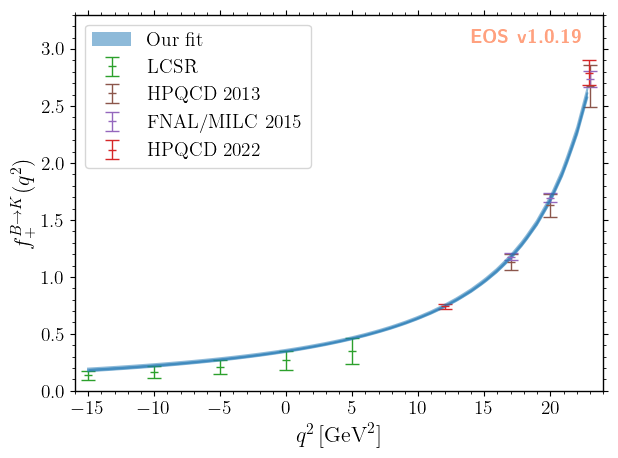

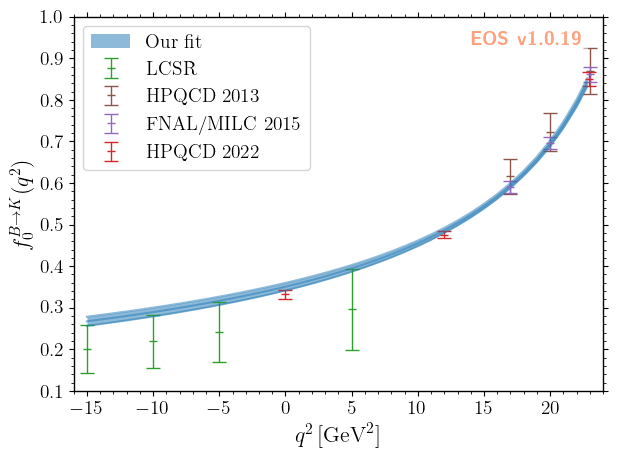

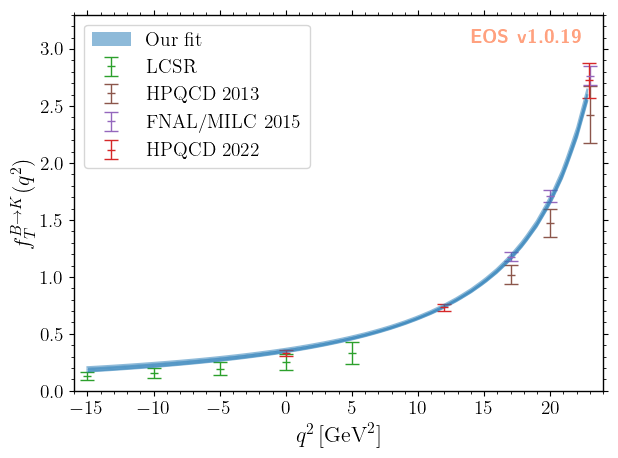

In [4]:
form_factors = [
    ('B->K::f_+(q2)',  r'f_+^{B \to K}(q^2)',   [0.0, 3.3],  'BToK-f+'),
    ('B->K::f_0(q2)',  r'f_0^{B \to K}(q^2)',   [0.1, 1.0],  'BToK-f0'),
    ('B->K::f_T(q2)',  r'f_T^{B \to K}(q^2)',   [0.0, 3.3],  'BToK-fT'),
]
for qn, latex, yrange, pred in form_factors:
	plot_args = {
		'plot': {
			'x': { 'label': r'$q^2$',      'unit': r'$\textnormal{GeV}^2$', 'range': [-16.0, 24.0] },
			'y': { 'label': fr'${latex}$',                                  'range': yrange         },
			'legend': { 'location': 'upper left' }
		},
		'contents': [
			{
				'label': r'LCSR',
				'type': 'constraint',
				'constraints': 'B->K::FormFactors[f_+,f_0,f_T]@GKvD:2018A',
				'observable': qn,
				'variable': 'q2',
				'color': 'C2',
			},
			{
				'label': r'HPQCD 2013',
				'type': 'constraint',
				'constraints': 'B->K::f_0+f_++f_T@HPQCD:2013A',
				'observable': qn,
				'variable': 'q2',
				'color': 'C5',
			},
			{
				'label': r'FNAL/MILC 2015',
				'type': 'constraint',
				'constraints': 'B->K::f_0+f_++f_T@FNAL+MILC:2015D',
				'observable': qn,
				'variable': 'q2',
				'color': 'C4',
			},
			{
				'label': r'HPQCD 2022',
				'type': 'constraint',
				'constraints': 'B->K::f_0+f_++f_T@HPQCD:2022A',
				'observable': qn,
				'variable': 'q2',
				'color': 'C3',
			},
			{
          		'label': r'Our fit','type': 'uncertainty', 'range': [-15.0, 22.8],
				'color': 'C0',
          		'data-file': f'{BASE_DIRECTORY}/data/{POSTERIOR_NAME}/pred-{pred}',
			}
		]
	}
	eos.plot.Plotter(plot_args).plot()

	#, f'./plots/BSZ-{pred}.pdf'

Print mean values parameters

In [7]:
print_params_from_posterior(BASE_DIRECTORY, POSTERIOR_NAME)

B->K::alpha^f+_0@BSZ2015: 3.924350e-01 ± 1.69e-02
B->K::alpha^f+_1@BSZ2015: -5.165001e-01 ± 1.43e-01
B->K::alpha^f+_2@BSZ2015: 4.366670e-01 ± 3.34e-01
B->K::alpha^f0_1@BSZ2015: 7.594723e-01 ± 1.24e-01
B->K::alpha^f0_2@BSZ2015: 7.289649e-01 ± 2.22e-01
B->K::alpha^fT_0@BSZ2015: 3.681986e-01 ± 1.89e-02
B->K::alpha^fT_1@BSZ2015: -6.828965e-01 ± 1.70e-01
B->K::alpha^fT_2@BSZ2015: 1.110318e-01 ± 3.84e-01
B->Kccbar::Re_Hhat_at_m7_plus@GRvDV2022: 4.175738e-05 ± 1.79e-05
B->Kccbar::Im_Hhat_at_m7_plus@GRvDV2022: -4.220369e-06 ± 6.51e-07
B->Kccbar::Re_Hhat_at_m5_plus@GRvDV2022: 1.027885e-04 ± 1.99e-05
B->Kccbar::Im_Hhat_at_m5_plus@GRvDV2022: -5.254976e-06 ± 7.10e-07
B->Kccbar::Re_Hhat_at_m3_plus@GRvDV2022: 1.666082e-04 ± 2.17e-05
B->Kccbar::Im_Hhat_at_m3_plus@GRvDV2022: -6.629269e-06 ± 7.87e-07
B->Kccbar::Re_Hhat_at_m1_plus@GRvDV2022: 2.335951e-04 ± 2.54e-05
B->Kccbar::Im_Hhat_at_m1_plus@GRvDV2022: -8.511313e-06 ± 8.89e-07
B->Kccbar::Abs_Hhat_at_Jpsi_plus@GRvDV2022: 1.224910e-03 ± 1.28e-05
B->Kcc

Print Selected Predictions

In [ ]:
pred_names = ['BToK-F0', 'BToK-FT0', 'BToK-Re(H0)', 'BToK-Im(H0)']
obs_names = ['B->K::F_plus(q2)', 'B->K::F_plus_T(q2)', 'B->K::Re{H_plus}(q2)', 'B->K::Im{H_plus}(q2)']

# pred_names = ['pred-BToK-Re(H0)', 'pred-BToK-Im(H0)'] 
# obs_names = ['B->K::Re{H_plus}(q2)', 'B->K::Im{H_plus}(q2)'] 

q2_vals = [-7.0, -5.0, -3.0, -1.0]
for pred_name, obs_name in zip(pred_names, obs_names):
    print_pred_from_posterior(BASE_DIRECTORY, POSTERIOR_NAME, pred_name, obs_name, q2_vals)

B->K::F_plus(q2) at q^2=-7.0: 2.433329e-01 ± 1.25e-02
B->K::F_plus(q2) at q^2=-5.0: 2.670316e-01 ± 1.26e-02
B->K::F_plus(q2) at q^2=-3.0: 2.941838e-01 ± 1.27e-02
B->K::F_plus(q2) at q^2=-1.0: 3.255292e-01 ± 1.28e-02
B->K::F_plus_T(q2) at q^2=-7.0: -5.169990e-02 ± 2.73e-03
B->K::F_plus_T(q2) at q^2=-5.0: -4.086678e-02 ± 1.97e-03
B->K::F_plus_T(q2) at q^2=-3.0: -2.722997e-02 ± 1.19e-03
B->K::F_plus_T(q2) at q^2=-1.0: -1.012032e-02 ± 4.05e-04
B->K::Re{H_plus}(q2) at q^2=-7.0: 2.819981e-06 ± 7.83e-07
B->K::Re{H_plus}(q2) at q^2=-5.0: 5.676047e-06 ± 7.54e-07
B->K::Re{H_plus}(q2) at q^2=-3.0: 6.374483e-06 ± 6.51e-07
B->K::Re{H_plus}(q2) at q^2=-1.0: 3.473176e-06 ± 3.15e-07
B->K::Im{H_plus}(q2) at q^2=-7.0: -3.003420e-07 ± 3.50e-08
B->K::Im{H_plus}(q2) at q^2=-5.0: -2.999540e-07 ± 3.16e-08
B->K::Im{H_plus}(q2) at q^2=-3.0: -2.592168e-07 ± 2.52e-08
B->K::Im{H_plus}(q2) at q^2=-1.0: -1.292462e-07 ± 1.16e-08


## 4.3.1 Covariance matrix

In [ ]:
pred_re = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', POSTERIOR_NAME, 'pred-BToK-Re(H0(F))-over-F0'))
pred_im = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', POSTERIOR_NAME, 'pred-BToK-Im(H0(F))-over-F0'))

obs_re = 'B->K::Re{H_0(q2,F)}/F_0(q2)'
obs_im = 'B->K::Im{H_0(q2,F)}/F_0(q2)'

q2_vals = [-7.0, -5.0, -3.0, -1.0]
idx_re = [find_index_for_q2(pred_re, obs_re, q2)[0] for q2 in q2_vals]
idx_im = [find_index_for_q2(pred_im, obs_im, q2)[0] for q2 in q2_vals]

# X: [Re(-7), Re(-5), Re(-3), Re(-1), Im(-7), Im(-5), Im(-3), Im(-1)]
X = np.hstack([
    pred_re.samples[:, idx_re],
    pred_im.samples[:, idx_im]
])

assert pred_re.samples.shape[0] == pred_im.samples.shape[0], "N sample is different between Re and Im"
assert np.allclose(pred_re.weights, pred_im.weights, rtol=0, atol=0), "Weights differ between Re and Im predictions"

mean_vec, cov_mat = weighted_mean_cov(X, pred_re.weights, unbiased=False)

print("mean vector =", mean_vec)
print("cov matrix shape =", cov_mat.shape)
print(cov_mat)
print("Condition number:\t", np.linalg.cond(cov_mat))

reg_cov_mat = cov_mat + 1e-19 * np.eye(cov_mat.shape[0])
print("Regulated cov matrix\n",reg_cov_mat.tolist())
print("Condition number:\t", np.linalg.cond(reg_cov_mat))

mean vector = [ 1.06082620e-05  2.06045223e-05  2.12729597e-05  1.05640133e-05
 -1.27352325e-06 -1.15184732e-06 -8.99043864e-07 -4.03865627e-07]
cov matrix shape = (8, 8)
[[4.11155080e-12 2.73703606e-12 1.51885162e-12 4.63866567e-13
  1.58522390e-13 1.19371208e-13 7.59804745e-14 2.70559313e-14]
 [2.73703606e-12 1.82953150e-12 1.02010470e-12 3.13297886e-13
  1.05527456e-13 7.97919289e-14 5.10306856e-14 1.82737164e-14]
 [1.51885162e-12 1.02010470e-12 5.71914868e-13 1.76774275e-13
  5.85598961e-14 4.44901450e-14 2.86100121e-14 1.03107078e-14]
 [4.63866567e-13 3.13297886e-13 1.76774275e-13 5.50432323e-14
  1.78845502e-14 1.36639585e-14 8.84312410e-15 3.21050495e-15]
 [1.58522390e-13 1.05527456e-13 5.85598961e-14 1.78845502e-14
  6.11189043e-15 4.60240189e-15 2.92945581e-15 1.04315162e-15]
 [1.19371208e-13 7.97919289e-14 4.44901450e-14 1.36639585e-14
  4.60240189e-15 3.47999031e-15 2.22561723e-15 7.96977299e-16]
 [7.59804745e-14 5.10306856e-14 2.86100121e-14 8.84312410e-15
  2.92945581e-15 

In [ ]:
def alpha_s_local(mu = 4.18):
    pp = eos.Parameters.Defaults()
    oo = eos.Options()
    mm = eos.Model.make('SM', pp, oo)

    return mm.alpha_s(mu)

cov_correction = [((alpha_s_local()/np.pi) * mean_vec[i])**2 for i in range(len(mean_vec))]

cov_mat_corrected = reg_cov_mat + np.diag(cov_correction)

# testarray = np.array([1.0, 2.0, 3.0])
# print(np.eye(3) + np.diag(testarray))

eigvals_reg = np.linalg.eigvalsh(cov_mat_corrected)
print("Eigenvalues of reg_cov_mat:")
print(eigvals_reg)

print(cov_mat_corrected)
print("Condition number after correction:\t", np.linalg.cond(cov_mat_corrected))
print(cov_mat_corrected.tolist(),'\n')

Autovalori reg_cov_mat:
[8.77276033e-16 4.36699433e-15 7.21012556e-15 9.30129523e-15
 5.86505225e-13 1.55009437e-12 2.33784575e-12 7.86429141e-12]
[[4.70024913e-12 2.73703606e-12 1.51885162e-12 4.63866567e-13
  1.58522390e-13 1.19371208e-13 7.59804745e-14 2.70559313e-14]
 [2.73703606e-12 4.05043341e-12 1.02010470e-12 3.13297886e-13
  1.05527456e-13 7.97919289e-14 5.10306856e-14 1.82737164e-14]
 [1.51885162e-12 1.02010470e-12 2.93925200e-12 1.76774275e-13
  5.85598961e-14 4.44901450e-14 2.86100121e-14 1.03107078e-14]
 [4.63866567e-13 3.13297886e-13 1.76774275e-13 6.38840706e-13
  1.78845502e-14 1.36639585e-14 8.84312410e-15 3.21050495e-15]
 [1.58522390e-13 1.05527456e-13 5.85598961e-14 1.78845502e-14
  1.45963295e-14 4.60240189e-15 2.92945581e-15 1.04315162e-15]
 [1.19371208e-13 7.97919289e-14 4.44901450e-14 1.36639585e-14
  4.60240189e-15 1.04206436e-14 2.22561723e-15 7.96977299e-16]
 [7.59804745e-14 5.10306856e-14 2.86100121e-14 8.84312410e-15
  2.92945581e-15 2.22561723e-15 5.6596166

In [ ]:
bfp, gof = eos.tasks.find_mode(
        ANALYSIS_FILE,
        POSTERIOR_NAME,
        BASE_DIRECTORY,
        importance_samples=True,
        label='EOS',
        optimizations=50
    )
display(bfp)
display(gof)

Inserting custom observables ...
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C7_Qc}(-7) has been replaced.
Inserted observable: b->s::Re{Delta_C7_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C7_Qc}(-7) has been replaced.
Inserted observable: b->s::Im{Delta_C7_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C9_Qc}(-7) has been replaced.
Inserted observable: b->s::Re{Delta_C9_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C9_Qc}(-7) has been replaced.
Inserted observable: b->s::Im{Delta_C9_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C7_Qc}(-5) has been replaced.
Inserted observable: b->s::Re{Delta_C7_Qc}(-5)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C7_Qc}(-5) has been replaced.
Inserted observable: b->s::Im{Delta_C7_Qc}(-5)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{

Inserted observable: B->K::Re{Delta_H_0(-1)}/F_0(q2)
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{Delta_H_0(-1)}/F_0(q2) has been replaced.
Inserted observable: B->K::Im{Delta_H_0(-1)}/F_0(q2)
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{H_0}/F_0(q2) has been replaced.
Inserted observable: B->K::Re{H_0}/F_0(q2)
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{H_0}/F_0(q2) has been replaced.
Inserted observable: B->K::Im{H_0}/F_0(q2)
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{H_0(q2,F)} has been replaced.
Inserted observable: B->K::Re{H_0(q2,F)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{H_0(q2,F)} has been replaced.
Inserted observable: B->K::Im{H_0(q2,F)}
[ObservableEntries.insert_or_assign] Entry for observable B->K::Re{H_0(q2,F)}/F_0(q2) has been replaced.
Inserted observable: B->K::Re{H_0(q2,F)}/F_0(q2)
[ObservableEntries.insert_or_assign] Entry for observable B->K::Im{H_0(

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK-wSR-wNFF…

parameter,value
"$\alpha_{+,0}^{B \to K,\mathrm{BSZ2015}}$",0.3354
"$\alpha_{+,1}^{B \to K,\mathrm{BSZ2015}}$",-0.9371
"$\alpha_{+,2}^{B \to K,\mathrm{BSZ2015}}$",-0.2756
"$\alpha_{0,1}^{B \to K,\mathrm{BSZ2015}}$",0.3631
"$\alpha_{0,2}^{B \to K,\mathrm{BSZ2015}}$",0.0542
"$\alpha_{T,0}^{B \to K,\mathrm{BSZ2015}}$",0.3231
"$\alpha_{T,1}^{B \to K,\mathrm{BSZ2015}}$",-1.0194
"$\alpha_{T,2}^{B \to K,\mathrm{BSZ2015}}$",-0.3917
"$\mathrm{Re}\, \hat{\mathcal{H}}_+^{B\to Kc\bar{c}}(m7)$",0.0000
"$\mathrm{Im}\, \hat{\mathcal{H}}_+^{B\to Kc\bar{c}}(m7)$",-0.0000


In [33]:
p = eos.Parameters.Defaults()
p.set('b->s::c1', -0.287213)
p.set('b->s::c2', 1.009)
p.set("mass::b(MSbar)", 4.18)
p.set("mass::c", 1.44423)
p.set("sb::mu", 4.18)
p.set('mass::K_d', 0.493677)
p.set('mass::B_d', 5.27931)

for par, val in zip(bfp.analysis.varied_parameters, bfp.point):
    p.set(par.name(), float(val))

obs_at_bfp=[]

# obs_name = "B->K::Re{H_0(q2,F)}/F_0(q2)"
# for q2 in [-7.0, -5.0, -3.0, -1.0]:
#     val = eos.Observable.make(obs_name, p, eos.Kinematics({"q2": q2}), eos.Options({'form-factors':'BSZ2015'})).evaluate()
#     obs_at_bfp.append(val)
#     print(val)

# obs_name = "B->K::Im{H_0(q2,F)}/F_0(q2)"
# for q2 in [-7.0, -5.0, -3.0, -1.0]:
#     val = eos.Observable.make(obs_name, p, eos.Kinematics({"q2": q2}), eos.Options({'form-factors':'BSZ2015'})).evaluate()
#     obs_at_bfp.append(val)
#     print(val)

obs_name = "B->K::Re{H_0}/F_0(q2)"
for q2 in [-7.0, -5.0, -3.0, -1.0]:
    val = eos.Observable.make(obs_name, p, eos.Kinematics({"q2": q2}), eos.Options({'form-factors':'BSZ2015', 'nonlocal-formfactor':'GRvDV2022order5'})).evaluate()
    obs_at_bfp.append(val)
    print(val)

obs_name = "B->K::Im{H_0}/F_0(q2)"
for q2 in [-7.0, -5.0, -3.0, -1.0]:
    val = eos.Observable.make(obs_name, p, eos.Kinematics({"q2": q2}), eos.Options({'form-factors':'BSZ2015', 'nonlocal-formfactor':'GRvDV2022order5'})).evaluate()
    obs_at_bfp.append(val)
    print(val)

1.0464544568919166e-05
2.05071973221879e-05
2.121819949929964e-05
1.0547123707916013e-05
-1.2790643509486742e-06
-1.156092030197853e-06
-9.017832080388269e-07
-4.0485076068243097e-07


In [34]:
y = np.asarray(obs_at_bfp, dtype=float) - mean_vec

chi2 = y.T @ np.linalg.solve(cov_mat, y)
print("chi2 =", chi2)

chi2_reg = y.T @ np.linalg.solve(cov_mat_corrected, y)
print("chi2_reg =", chi2_reg)

chi2 = -818.0981190800667
chi2_reg = 0.0046139159512734364


## 4.4 From L-poly To Monomials

$V$ is Vandermonde's matrix 

$h_i = V_{in} \, c_n \\$ 
$c_n = (V^{-1})_{ni} \, h_i$

In [ ]:
def zhat(q2):
    mD = 5.27931 # see posteriors in yaml file!!!
    s_plus = 4.0 * mD**2
    s_0 = 4.0 # GeV2

    sqrt_minus_q2 = np.sqrt(s_plus - q2)
    sqrt_minus_s0 = np.sqrt(s_plus - s_0)
    
    return (sqrt_minus_q2 - sqrt_minus_s0) / (sqrt_minus_q2 + sqrt_minus_s0)

In [24]:
q2_nodes = [-7.0, -5.0, -3.0, -1.0, 3.0969**2, 3.686097**2] # pdg values for J/psi and psi(2S) masses

zhat_nodes = [zhat(q2) for q2 in q2_nodes]
print(zhat_nodes)

[np.float64(0.024354067556466522), np.float64(0.020100191706261573), np.float64(0.01577189613325132), np.float64(0.011366710757579937), np.float64(-0.013353320848882688), np.float64(-0.023352967278885844)]


In [ ]:
V = np.vander(zhat_nodes, N=6, increasing=True)
V

array([[ 1.00000000e+00,  2.43540676e-02,  5.93120607e-04,
         1.44448993e-05,  3.51792054e-07,  8.56756745e-09],
       [ 1.00000000e+00,  2.01001917e-02,  4.04017707e-04,
         8.12083336e-06,  1.63230307e-07,  3.28096047e-09],
       [ 1.00000000e+00,  1.57718961e-02,  2.48752708e-04,
         3.92330187e-06,  6.18779096e-08,  9.75931962e-10],
       [ 1.00000000e+00,  1.13667108e-02,  1.29202113e-04,
         1.46860305e-06,  1.66931861e-08,  1.89746618e-10],
       [ 1.00000000e+00, -1.33533208e-02,  1.78311178e-04,
        -2.38104637e-06,  3.17948761e-08, -4.24567182e-10],
       [ 1.00000000e+00, -2.33529673e-02,  5.45361081e-04,
        -1.27357995e-05,  2.97418708e-07, -6.94560936e-09]])

In [12]:
np.linalg.cond(V)

np.float64(17984531292.26052)

In [14]:
V_inv = np.linalg.inv(V)
V_inv

array([[-1.31746360e+00,  5.82464419e+00, -9.30545432e+00,
         5.61422638e+00,  2.25663583e-01, -4.16162324e-02],
       [ 1.09905495e+02, -4.35288295e+02,  5.68368040e+02,
        -2.04957103e+02, -4.49907013e+01,  6.96256420e+00],
       [ 9.69494596e+03, -4.45666527e+04,  7.26389457e+04,
        -4.01144120e+04,  2.48162404e+03, -1.34450947e+02],
       [-8.17603208e+05,  3.15745148e+06, -3.98099239e+06,
         1.65140073e+06,  2.23873290e+04, -3.26439418e+04],
       [-1.23486719e+07,  6.32571864e+07, -1.02510131e+08,
         5.48450981e+07, -5.31172245e+06,  2.06824045e+06],
       [ 1.17243386e+09, -4.27806937e+09,  5.36290016e+09,
        -2.33186257e+09,  1.10110564e+08, -3.55126477e+07]])

In [13]:
V_pinv = np.linalg.pinv(V)
V_pinv

array([[-1.31746360e+00,  5.82464419e+00, -9.30545432e+00,
         5.61422638e+00,  2.25663583e-01, -4.16162324e-02],
       [ 1.09905495e+02, -4.35288295e+02,  5.68368040e+02,
        -2.04957103e+02, -4.49907013e+01,  6.96256420e+00],
       [ 9.69494596e+03, -4.45666527e+04,  7.26389457e+04,
        -4.01144120e+04,  2.48162404e+03, -1.34450947e+02],
       [-8.17603208e+05,  3.15745148e+06, -3.98099239e+06,
         1.65140073e+06,  2.23873290e+04, -3.26439418e+04],
       [-1.23486719e+07,  6.32571864e+07, -1.02510131e+08,
         5.48450981e+07, -5.31172245e+06,  2.06824045e+06],
       [ 1.17243386e+09, -4.27806937e+09,  5.36290016e+09,
        -2.33186257e+09,  1.10110564e+08, -3.55126477e+07]])

### 4.4.1 numerical check

In [ ]:
(V_inv - V_pinv) / V_inv # good

array([[-3.85955365e-14, -6.25193814e-15,  1.67986856e-14,
         3.13238753e-14, -1.04177077e-13, -2.25426090e-13],
       [-1.18698019e-13, -4.19187413e-14,  3.02035148e-14,
         1.24804352e-13, -1.16237231e-13, -3.14447342e-13],
       [-3.56482633e-15,  5.71410462e-15,  1.42235817e-14,
         2.04959557e-14,  1.97905538e-14,  1.06752415e-13],
       [-2.86196036e-14, -5.60424412e-15,  2.07038948e-14,
         5.17432533e-14, -4.96605166e-13, -1.27603638e-13],
       [ 1.20670152e-14,  1.01292828e-14,  1.25012021e-14,
         1.52149427e-14, -8.76667205e-16, -5.29099033e-15],
       [ 8.54084878e-15,  9.13978797e-15,  1.47597318e-14,
         2.20846690e-14, -1.12323136e-14, -3.79739382e-14]])

In [22]:
print(np.linalg.norm(V @ V_pinv - np.eye(V.shape[0])))
print(np.linalg.norm(V @ V_inv - np.eye(V.shape[0])))

5.550184626568959e-13
3.5817632951183365e-14


In [17]:
y = np.random.randn(V.shape[0])

rel = np.linalg.norm(V_inv @ y - V_pinv @ y) / np.linalg.norm(V_inv @ y)
rel


np.float64(1.6501720294236196e-14)

In [19]:
I1 = V @ V_inv
I2 = V_inv @ V
print(np.linalg.norm(I1 - np.eye(V.shape[0])) / np.linalg.norm(np.eye(V.shape[0])))
print(np.linalg.norm(I2 - np.eye(V.shape[0])) / np.linalg.norm(np.eye(V.shape[0])))

1.4622487420782738e-14
1.887335297502396e-07


# 5. Predictions

In [ ]:
eos.tasks.predict_observables(ANALYSIS_FILE, POSTERIOR_NAME, 'BToKll-Normalized-BR', BASE_DIRECTORY)

Inserting custom observables ...


Inserted observable: b->s::Re{Delta_C7_Qc}(-7)
Inserted observable: b->s::Im{Delta_C7_Qc}(-7)
Inserted observable: b->s::Re{Delta_C9_Qc}(-7)
Inserted observable: b->s::Im{Delta_C9_Qc}(-7)
Inserted observable: b->s::Re{Delta_C7_Qc}(-5)
Inserted observable: b->s::Im{Delta_C7_Qc}(-5)
Inserted observable: b->s::Re{Delta_C9_Qc}(-5)
Inserted observable: b->s::Im{Delta_C9_Qc}(-5)
Inserted observable: b->s::Re{Delta_C7_Qc}(-3)
Inserted observable: b->s::Im{Delta_C7_Qc}(-3)
Inserted observable: b->s::Re{Delta_C9_Qc}(-3)
Inserted observable: b->s::Im{Delta_C9_Qc}(-3)
Inserted observable: b->s::Re{Delta_C7_Qc}(-1)
Inserted observable: b->s::Im{Delta_C7_Qc}(-1)
Inserted observable: b->s::Re{Delta_C9_Qc}(-1)
Inserted observable: b->s::Im{Delta_C9_Qc}(-1)
Inserted observable: B->K::Re{H_0(-7,F)}
Inserted observable: B->K::Im{H_0(-7,F)}
Inserted observable: B->K::Re{H_0(-5,F)}
Inserted observable: B->K::Im{H_0(-5,F)}
Inserted observable: B->K::Re{H_0(-3,F)}
Inserted observable: B->K::Im{H_0(-3,F)}
In

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK-wSR-wNFF…

   plotting uncertainty propagation from "./test_base/data/BSZ-BqToK-wSR-wNFF-wCov/pred-BToKll-Normalized-BR"


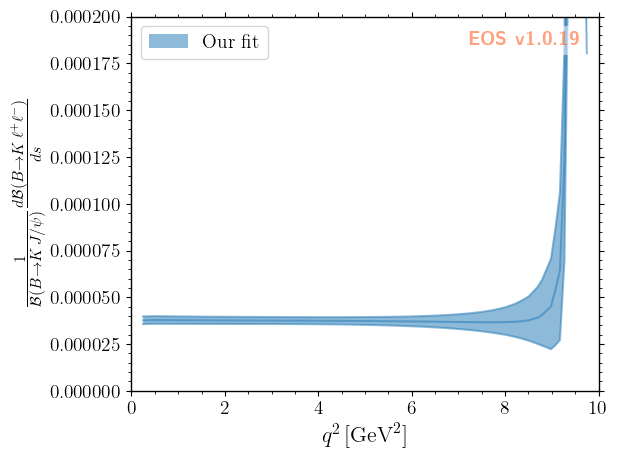

In [ ]:
q2_vals = np.linspace(0,10,1000)

pred_import = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', POSTERIOR_NAME, 'pred-BToKll-Normalized-BR'))
obs_name = 'B->Kll::Normalized_dBR/ds'
yrange = range_from_pred(pred_import, obs_name, q2_vals, nsigma=1.5, pad_frac=0.1)

to_plot = [
    (obs_name, R'\frac{1}{\mathcal{B}(B \to K\, J/\psi)}\frac{d\mathcal{B}(B \to K\, \ell^+\ell^-)}{ds}', [0,0.0002], 'BToKll-Normalized-BR'),
]

for qn, latex, yrange, pred in to_plot:
	plot_args = {
		'plot': {
			'x': { 'label': r'$q^2$',      'unit': r'$\textnormal{GeV}^2$', 'range': [0.0, 10.0] },
			'y': { 'label': fr'${latex}$',                                  'range': yrange         },
			'legend': { 'location': 'upper left' }
		},
		'contents': [
			{
          		'label': r'Our fit','type': 'uncertainty', 'range': [0, 10],
				'color': 'C0',
          		'data-file': f'{BASE_DIRECTORY}/data/{POSTERIOR_NAME}/pred-{pred}',
			}
		]
	}
	eos.plot.Plotter(plot_args).plot()
#, f'./plots/{POSTERIOR_NAME}-{pred}.pdf'

In [ ]:
eos.tasks.predict_observables(ANALYSIS_FILE, POSTERIOR_NAME, 'BToK-strong-bound', BASE_DIRECTORY)

Inserting custom observables ...
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C7_Qc}(-7) has been replaced.
Inserted observable: b->s::Re{Delta_C7_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C7_Qc}(-7) has been replaced.
Inserted observable: b->s::Im{Delta_C7_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C9_Qc}(-7) has been replaced.
Inserted observable: b->s::Re{Delta_C9_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C9_Qc}(-7) has been replaced.
Inserted observable: b->s::Im{Delta_C9_Qc}(-7)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C7_Qc}(-5) has been replaced.
Inserted observable: b->s::Re{Delta_C7_Qc}(-5)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C7_Qc}(-5) has been replaced.
Inserted observable: b->s::Im{Delta_C7_Qc}(-5)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{

[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C7_Qc}(-3) has been replaced.
Inserted observable: b->s::Im{Delta_C7_Qc}(-3)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C9_Qc}(-3) has been replaced.
Inserted observable: b->s::Re{Delta_C9_Qc}(-3)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C9_Qc}(-3) has been replaced.
Inserted observable: b->s::Im{Delta_C9_Qc}(-3)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C7_Qc}(-1) has been replaced.
Inserted observable: b->s::Re{Delta_C7_Qc}(-1)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C7_Qc}(-1) has been replaced.
Inserted observable: b->s::Im{Delta_C7_Qc}(-1)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Re{Delta_C9_Qc}(-1) has been replaced.
Inserted observable: b->s::Re{Delta_C9_Qc}(-1)
[ObservableEntries.insert_or_assign] Entry for observable b->s::Im{Delta_C9_Qc}(-1) has been replace

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK-wSR-wNFF…

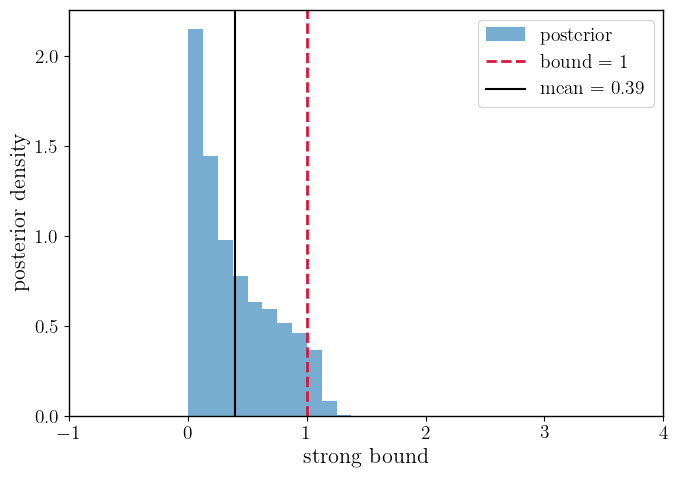

In [ ]:
pred = eos.data.Prediction(
    os.path.join(BASE_DIRECTORY, 'data', POSTERIOR_NAME, 'pred-BToK-strong-bound')
)

samples = pred.samples[:, 0]
weights = pred.weights / np.sum(pred.weights)

mean = np.average(samples, weights=weights)

plt.figure(figsize=(7,5))
plt.hist(samples, bins=7500, weights=weights, density=True, alpha=0.6, color='C0', label='posterior')
plt.axvline(1.0, color='crimson', linestyle='--', linewidth=1.5, label='bound = 1')
plt.axvline(mean, color='black', linestyle='-', linewidth=1.5, label=f'mean = {mean:.2f}')

plt.xlim(-1, 4)
plt.xlabel(r'$\mathrm{strong\ bound}$')
plt.ylabel('posterior density')
plt.legend()
plt.tight_layout()
plt.show()
